# Londres - Análise de Airbnb
## Notebook de Arthur Vinicius Machado e Mateus Batichotti Silva

Dados obtidos em [Inside Airbnb](https://insideairbnb.com/london/) e analisados com Python. O objetivo é analisar os dados de Airbnb em Londres, buscando insights sobre preços, tipos de acomodações, localização e outros fatores relevantes para entender o mercado de aluguel de curto prazo na cidade.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

Blablabla

In [3]:
original_df = pd.read_csv("./listings.csv")

In [4]:
df = original_df[['id', 'name', 'host_id', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']]

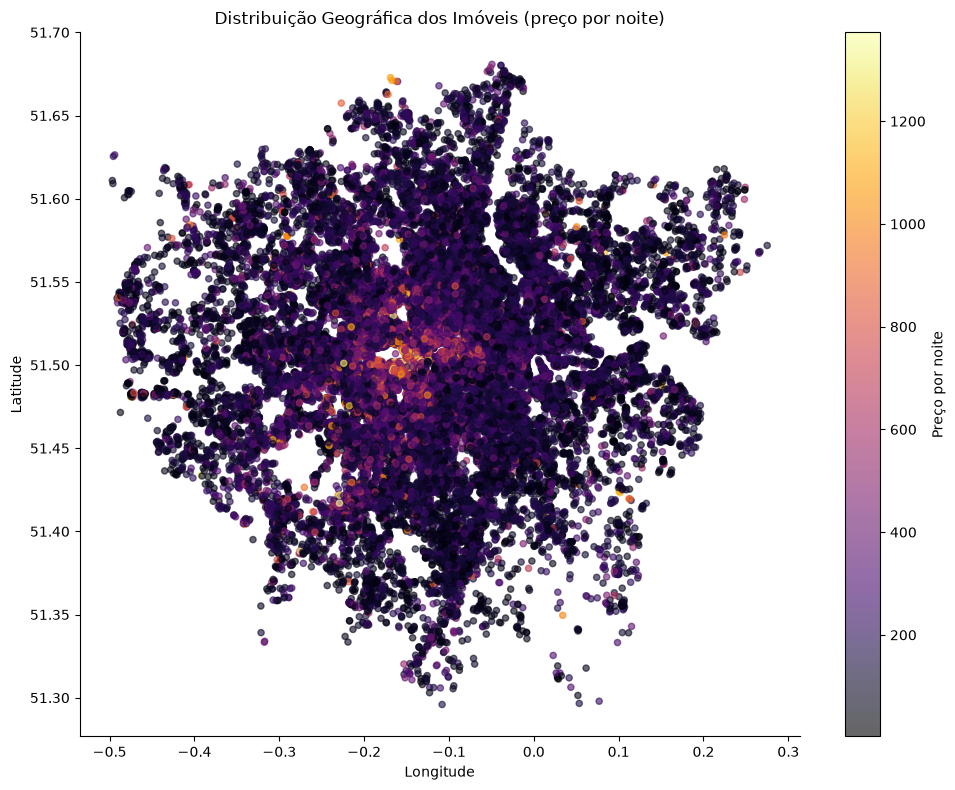

In [39]:

# Remove linhas sem preço por noite ou sem coordenadas
df_plot = df.dropna(subset=['price_quote_price_per_night', 'latitude', 'longitude']).copy()

# Remove outliers extremos (ex: acima do percentil 99)
limite = df_plot['price_quote_price_per_night'].quantile(0.99)
df_plot = df_plot[df_plot['price_quote_price_per_night'] <= limite]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_plot['longitude'], df_plot['latitude'], c=df_plot['price_quote_price_per_night'], 
                      cmap='inferno', alpha=0.6, s=20)
plt.colorbar(scatter, label='Preço por noite')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Imóveis (preço por noite)')

# Remove bordas superior e direita
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

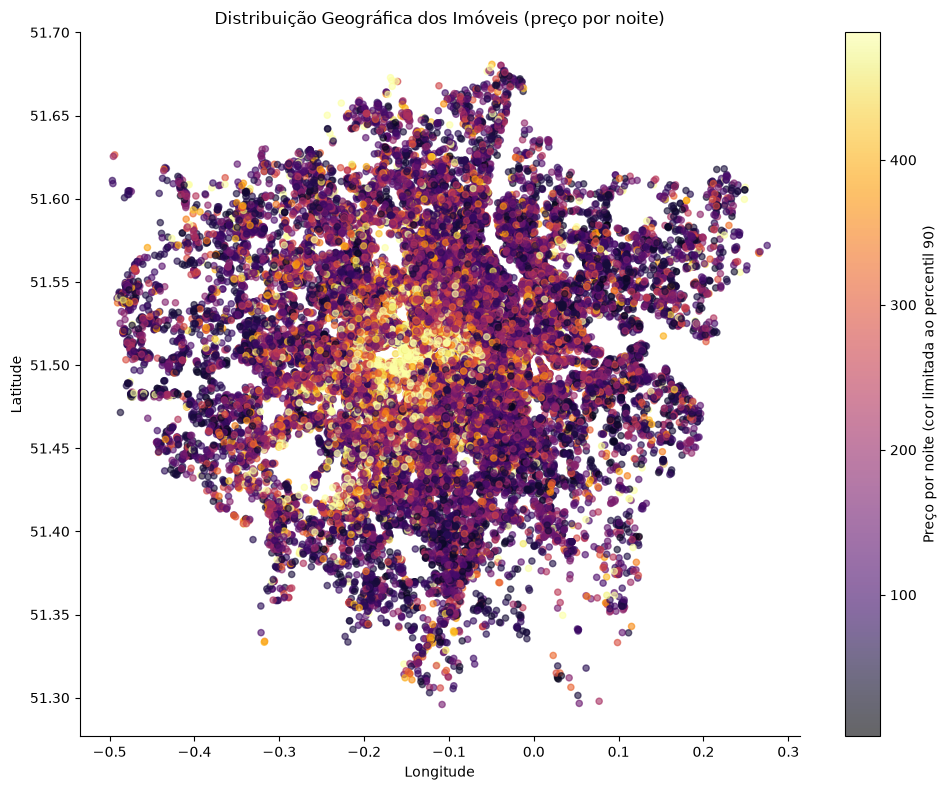

In [38]:
df_plot = df.dropna(subset=['price_quote_price_per_night', 'latitude', 'longitude']).copy()

vmax = df_plot['price_quote_price_per_night'].quantile(0.90)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_plot['longitude'], df_plot['latitude'], c=df_plot['price_quote_price_per_night'], 
                      cmap='inferno', alpha=0.6, s=20, vmax=vmax)
plt.colorbar(scatter, label='Preço por noite (cor limitada ao percentil 90)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Imóveis (preço por noite)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()